In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', "{:.3f}".format)


Loading data and basic cleaning

In [110]:
df = pd.read_csv("loan.csv")
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns.tolist())
df.head()

Shape of the dataset: (614, 13)
Columns in the dataset: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [112]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [113]:
df.columns = [i.lower() for i in df.columns]
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [114]:
df = df.drop(columns=["loan_id"])

In [115]:
target_col = "loan_status"

In [116]:
df[target_col] = df[target_col].map({"Y": 1, "N": 0})

In [117]:
df["loan_status"].value_counts()

loan_status
1    422
0    192
Name: count, dtype: int64

train test split

In [118]:
x = df.drop(columns=[target_col])
y = df[target_col]

In [119]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [120]:
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (491, 11)
Shape of x_test: (123, 11)
Shape of y_train: (491,)
Shape of y_test: (123,)


In [121]:
x_train_processed = x_train.copy()
x_test_processed = x_test.copy()

identify num and cat colums

In [122]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             480 non-null    object 
 1   married            488 non-null    object 
 2   dependents         483 non-null    object 
 3   education          491 non-null    object 
 4   self_employed      464 non-null    object 
 5   applicantincome    491 non-null    int64  
 6   coapplicantincome  491 non-null    float64
 7   loanamount         471 non-null    float64
 8   loan_amount_term   479 non-null    float64
 9   credit_history     448 non-null    float64
 10  property_area      491 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 46.0+ KB


In [123]:
num_cols = x_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = x_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']
Categorical columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'property_area']


missing values
used median for num cols
used mode for cat cals

In [124]:
print("Missing values in numerical columns:")
for col in num_cols:
    print(f"{col}: {x_train[col].isnull().sum()}")
print("-"*50)
print("Missing values in categorical columns:")
for col in cat_cols:
    print(f"{col}: {x_train[col].isnull().sum()}")

Missing values in numerical columns:
applicantincome: 0
coapplicantincome: 0
loanamount: 20
loan_amount_term: 12
credit_history: 43
--------------------------------------------------
Missing values in categorical columns:
gender: 11
married: 3
dependents: 8
education: 0
self_employed: 27
property_area: 0


In [125]:
if num_cols:
    num_imputer = SimpleImputer(strategy="median")
    x_train_processed[num_cols] = num_imputer.fit_transform(x_train_processed[num_cols])
    x_test_processed[num_cols] = num_imputer.transform(x_test_processed[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    x_train_processed[cat_cols] = cat_imputer.fit_transform(x_train_processed[cat_cols])
    x_test_processed[cat_cols] = cat_imputer.transform(x_test_processed[cat_cols])

print("Missing numerical values after imputation:")
for col in num_cols:
    print(f"{col}: {x_train_processed[col].isnull().sum()}")
    
print("-"*50)

print("Missing categorical values after imputaiton")
for col in cat_cols:
    print(f"{col}: {x_train_processed[col].isnull().sum()}") 



Missing numerical values after imputation:
applicantincome: 0
coapplicantincome: 0
loanamount: 0
loan_amount_term: 0
credit_history: 0
--------------------------------------------------
Missing categorical values after imputaiton
gender: 0
married: 0
dependents: 0
education: 0
self_employed: 0
property_area: 0


outliners

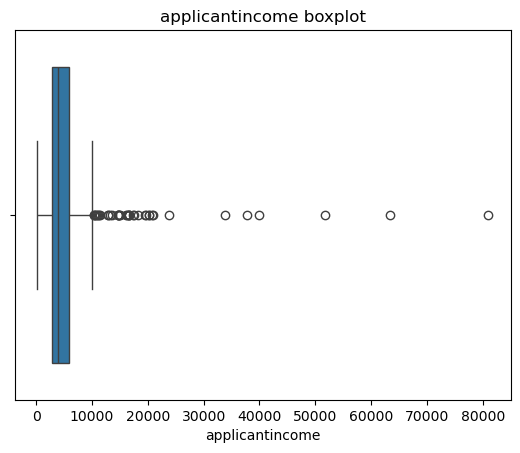

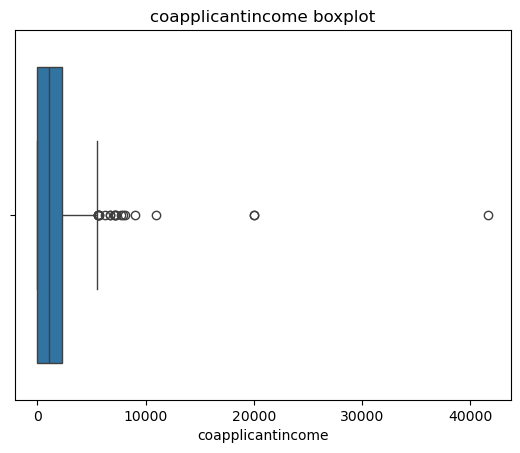

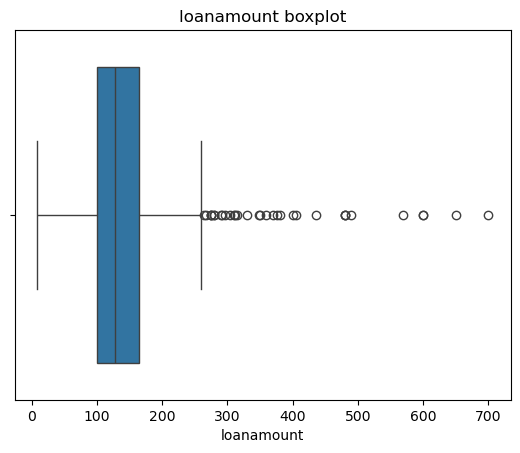

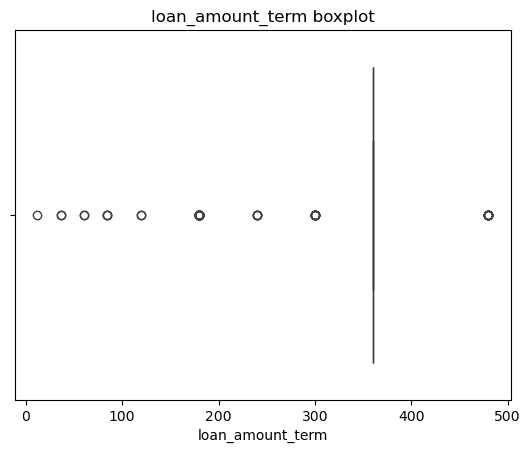

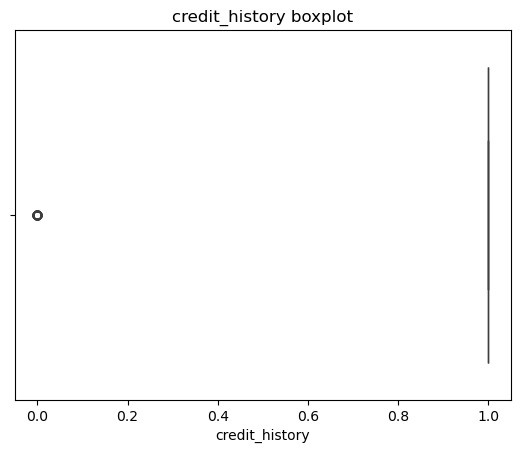

In [126]:
for i in num_cols:
    plt.figsize=(6,4)
    sns.boxplot(x = x_train_processed[i])
    plt.title(f"{i} boxplot")
    plt.show()

In [127]:
x_train_processed[num_cols].head()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
154,3254.000,0.000,50.000,360.000,1.000
239,3315.000,0.000,96.000,360.000,1.000
448,3340.000,1710.000,150.000,360.000,0.000
471,2653.000,1500.000,113.000,180.000,0.000
273,2620.000,2223.000,150.000,360.000,1.000


In [128]:
def iqr_bound (series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

def com_train_outliners(df, cols):
    bounds = {}
    for i in cols:
        low , high = iqr_bound(df[i])
        bounds[i] = (low, high)
    return bounds

def cap_outliers(df, bounds):
    df_capped = df.copy()
    for i, (low, high) in bounds.items():
        df_capped[i] = np.where(df_capped[i] < low, low, df_capped[i])
        df_capped[i] = np.where(df_capped[i] > high, high, df_capped[i])
    return df_capped

In [129]:
x_train_processed.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='object')

In [130]:
outlier_cols = ["applicantincome", "coapplicantincome", "loanamount"]
train_bound = com_train_outliners(x_train_processed, outlier_cols)

In [131]:
train_bound

{'applicantincome': (np.float64(-1472.5), np.float64(10203.5)),
 'coapplicantincome': (np.float64(-3361.5), np.float64(5602.5)),
 'loanamount': (np.float64(3.75), np.float64(261.75))}

In [132]:
x_train_processed[outlier_cols] = cap_outliers(x_train_processed[outlier_cols], train_bound)
x_test_processed[outlier_cols] = cap_outliers(x_test_processed[outlier_cols], train_bound)

cat cols encoding

In [133]:
for i in cat_cols:
    print(i,x_train_processed[i].unique())
    print("-"*50)

gender ['Male' 'Female']
--------------------------------------------------
married ['No' 'Yes']
--------------------------------------------------
dependents ['0' '1' '2' '3+']
--------------------------------------------------
education ['Graduate' 'Not Graduate']
--------------------------------------------------
self_employed ['No' 'Yes']
--------------------------------------------------
property_area ['Urban' 'Semiurban' 'Rural']
--------------------------------------------------


In [134]:
label_encoders = {}

for i in cat_cols:
    le = LabelEncoder()
    le.fit(x_train[i])
    label_encoders[i] = le
    
    x_train_processed[i] = le.fit_transform(x_train_processed[i])
    x_test_processed[i] = le.transform(x_test_processed[i])

In [135]:
print(label_encoders)

{'gender': LabelEncoder(), 'married': LabelEncoder(), 'dependents': LabelEncoder(), 'education': LabelEncoder(), 'self_employed': LabelEncoder(), 'property_area': LabelEncoder()}


In [136]:
x_train_processed[cat_cols].head()

,gender,married,dependents,education,self_employed,property_area
154,1,0,0,0,0,2
239,1,1,1,0,0,1
448,1,1,2,0,0,0
471,1,1,1,1,0,0
273,1,1,0,0,0,1


In [137]:
x_train_processed[num_cols].head()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
154,3254.000,0.000,50.000,360.000,1.000
239,3315.000,0.000,96.000,360.000,1.000
448,3340.000,1710.000,150.000,360.000,0.000
471,2653.000,1500.000,113.000,180.000,0.000
273,2620.000,2223.000,150.000,360.000,1.000


In [138]:
x_train_processed[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   gender         491 non-null    int64
 1   married        491 non-null    int64
 2   dependents     491 non-null    int64
 3   education      491 non-null    int64
 4   self_employed  491 non-null    int64
 5   property_area  491 non-null    int64
dtypes: int64(6)
memory usage: 26.9 KB


In [139]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("-"*50)
print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

loan_status
1    337
0    154
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


In [140]:
print(y_train.value_counts(normalize=True))
print("-"*50)
print(y_train.value_counts(normalize=True))

loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


In [141]:
smote = SMOTE(random_state=42)

In [142]:
x_train_processed, y_train_processed = smote.fit_resample(x_train_processed, y_train)

In [143]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("-"*50)
print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

loan_status
1    337
0    154
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


In [145]:
print(y_train.value_counts(normalize=True))
print("-"*50)
print(y_train.value_counts(normalize=True))

loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


standardization


In [146]:
scaler = StandardScaler()

In [149]:
x_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,3254.000,0.000,50.000,360.000,1.000,2
1,1,1,1,0,0,3315.000,0.000,96.000,360.000,1.000,1
2,1,1,2,0,0,3340.000,1710.000,150.000,360.000,0.000,0
3,1,1,1,1,0,2653.000,1500.000,113.000,180.000,0.000,0
4,1,1,0,0,0,2620.000,2223.000,150.000,360.000,1.000,1


In [150]:
x_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             674 non-null    int64  
 1   married            674 non-null    int64  
 2   dependents         674 non-null    int64  
 3   education          674 non-null    int64  
 4   self_employed      674 non-null    int64  
 5   applicantincome    674 non-null    float64
 6   coapplicantincome  674 non-null    float64
 7   loanamount         674 non-null    float64
 8   loan_amount_term   674 non-null    float64
 9   credit_history     674 non-null    float64
 10  property_area      674 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 58.1 KB


In [148]:
scale_cols = ["applicantincome", "coapplicantincome", "loanamount", "loan_amount_term"]

In [152]:
scaler.fit(x_train_processed[scale_cols])
x_train_processed[scale_cols] = scaler.transform(x_train_processed[scale_cols])
x_test_processed[scale_cols] = scaler.transform(x_test_processed[scale_cols])

In [153]:
x_train_processed

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,-0.607,-0.853,-1.642,0.270,1.000,2
1,1,1,1,0,0,-0.582,-0.853,-0.799,0.270,1.000,1
2,1,1,2,0,0,-0.572,0.216,0.191,0.270,0.000,0
3,1,1,1,1,0,-0.855,0.084,-0.487,-2.653,0.000,0
4,1,1,0,0,0,-0.868,0.536,0.191,0.270,1.000,1
...,...,...,...,...,...,...,...,...,...,...,...
669,1,0,1,0,0,-0.375,-0.853,-1.177,0.270,0.806,1
670,0,0,0,0,0,-0.535,-0.853,-0.283,-4.991,1.000,1
671,0,0,0,0,0,2.226,-0.853,1.081,0.270,0.300,1
672,1,1,0,0,0,-0.701,1.059,-0.106,0.270,0.138,1


In [154]:
x_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,-0.607,-0.853,-1.642,0.270,1.000,2
1,1,1,1,0,0,-0.582,-0.853,-0.799,0.270,1.000,1
2,1,1,2,0,0,-0.572,0.216,0.191,0.270,0.000,0
3,1,1,1,1,0,-0.855,0.084,-0.487,-2.653,0.000,0
4,1,1,0,0,0,-0.868,0.536,0.191,0.270,1.000,1


In [155]:
print("x_train_processed", x_train_processed.shape)
print("x_test_processed", x_test_processed.shape)
print("y_train_processed", y_train_processed.shape)
print("y_test", y_test.shape)

x_train_processed (674, 11)
x_test_processed (123, 11)
y_train_processed (674,)
y_test (123,)
